# ch231 — Newton's Method

**Advanced Calculus Experiment 1.**

Gradient descent uses only first-order information *(ch205)*. Newton's method uses the second derivative *(ch217)* to jump directly toward the minimum of a quadratic approximation. For well-conditioned problems it converges quadratically — the number of correct digits doubles each iteration.

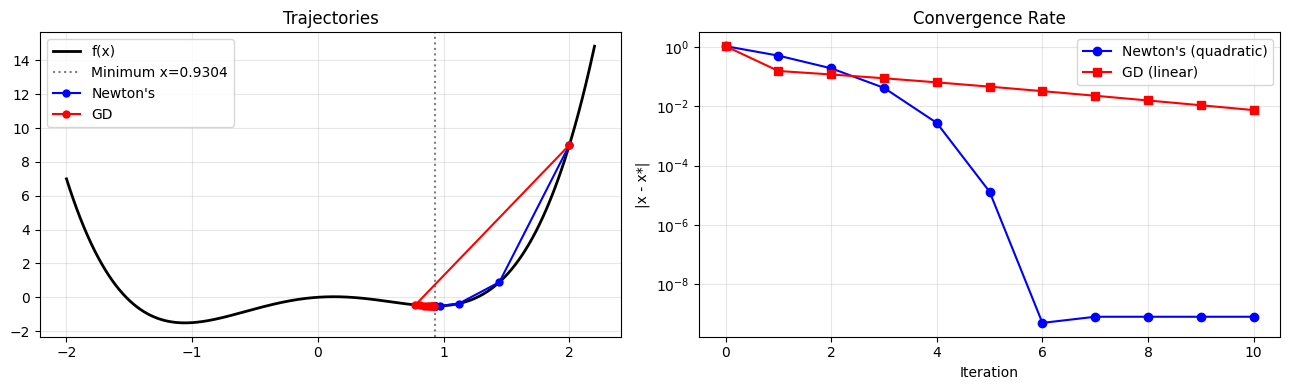

True minimum: 0.9304029273
Newton after 10 steps: 0.9304029266
GD after 10 steps: 0.9229711790


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Newton's method for minimisation: w_{t+1} = w_t - f''(w)^{-1} * f'(w)
# Example: minimise f(x) = x^4 - 2x^2 + 0.5x

def f(x): return x**4 - 2*x**2 + 0.5*x
def f1(x): return 4*x**3 - 4*x + 0.5
def f2(x): return 12*x**2 - 4

# Newton vs Gradient Descent from x=2.0
x0 = 2.0
n_steps = 10

x_n, x_g = x0, x0
newtons_path, gd_path = [x0], [x0]

lr_gd = 0.05
for _ in range(n_steps):
    # Newton step
    x_n = x_n - f1(x_n) / f2(x_n)
    newtons_path.append(x_n)
    # Gradient descent step
    x_g = x_g - lr_gd * f1(x_g)
    gd_path.append(x_g)

# True minimum
from scipy.optimize import minimize_scalar
result = minimize_scalar(f)
x_min = result.x

x_plot = np.linspace(-2, 2.2, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_plot, f(x_plot), 'k', lw=2, label='f(x)')
axes[0].axvline(x_min, color='gray', ls=':', label=f'Minimum x={x_min:.4f}')
for path, label, color in [(newtons_path, "Newton's", 'blue'), (gd_path, 'GD', 'red')]:
    axes[0].plot(path, f(np.array(path)), 'o-', color=color, ms=5, lw=1.5, label=label)
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_title('Trajectories')

# Convergence in error
n_err = [abs(x - x_min) for x in newtons_path]
g_err = [abs(x - x_min) for x in gd_path]
axes[1].semilogy(n_err, 'b-o', label="Newton's (quadratic)")
axes[1].semilogy(g_err, 'r-s', label='GD (linear)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('|x - x*|'); axes[1].set_title('Convergence Rate')
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch231_newton.png', dpi=100); plt.show()

print(f"True minimum: {x_min:.10f}")
print(f"Newton after {n_steps} steps: {newtons_path[-1]:.10f}")
print(f"GD after {n_steps} steps: {gd_path[-1]:.10f}")


## Newton's Method in Multiple Dimensions

In multiple dimensions, the scalar second derivative becomes the **Hessian matrix H**:

```
w_{t+1} = w_t - H^{-1} * gradient
```

This is exact for quadratic losses. For non-quadratic losses it is approximate but still converges much faster than gradient descent near the minimum.

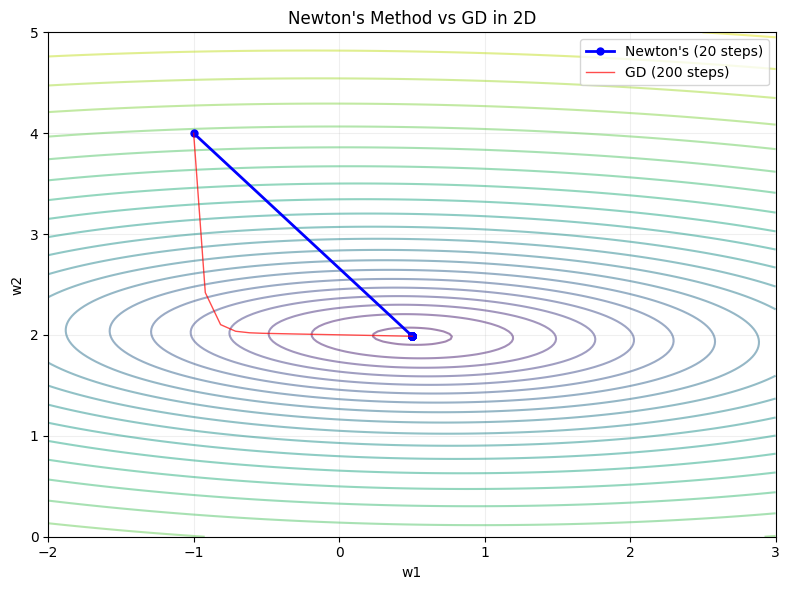

In [2]:
# 2D Newton's method
def loss_2d(w): return (w[0]-1)**2 + 10*(w[1]-2)**2 + 0.5*w[0]*w[1]
def grad_2d(w): return np.array([2*(w[0]-1) + 0.5*w[1], 20*(w[1]-2) + 0.5*w[0]])
def hessian_2d(w): return np.array([[2, 0.5], [0.5, 20]])

w = np.array([-1.0, 4.0])
path_newton = [w.copy()]
for _ in range(20):
    g = grad_2d(w); H = hessian_2d(w)
    w = w - np.linalg.solve(H, g)
    path_newton.append(w.copy())

w_gd = np.array([-1.0, 4.0])
path_gd = [w_gd.copy()]
for _ in range(200):
    w_gd = w_gd - 0.04 * grad_2d(w_gd)
    path_gd.append(w_gd.copy())

w1r = np.linspace(-2, 3, 200); w2r = np.linspace(0, 5, 200)
W1, W2 = np.meshgrid(w1r, w2r)
Z = (W1-1)**2 + 10*(W2-2)**2 + 0.5*W1*W2

plt.figure(figsize=(8, 6))
plt.contour(W1, W2, np.log1p(Z), levels=20, cmap='viridis', alpha=0.5)
pn = np.array(path_newton); pg = np.array(path_gd)
plt.plot(pn[:, 0], pn[:, 1], 'b-o', ms=5, lw=2, label=f"Newton's (20 steps)")
plt.plot(pg[:, 0], pg[:, 1], 'r-', lw=1, alpha=0.7, label='GD (200 steps)')
plt.xlabel('w1'); plt.ylabel('w2'); plt.title("Newton's Method vs GD in 2D")
plt.legend(); plt.grid(True, alpha=0.2)
plt.tight_layout(); plt.savefig('ch231_newton_2d.png', dpi=100); plt.show()


## Summary

| Method | Convergence | Cost per Step | Best for |
|---|---|---|---|
| GD | Linear | O(d) | Large-scale, non-convex |
| Newton's | Quadratic | O(d^3) (Hessian inversion) | Small-d, convex |
| L-BFGS | Super-linear | O(d·m) (approximation) | Medium-scale, smooth |

**Forward reference:** Quasi-Newton methods and L-BFGS are the practical compromise used in ch291 — Optimisation Methods (Part IX).